# Sentiment Analysis Using BERT

## 1. Project Overview

This project performs binary sentiment classification on movie reviews using the IMDB dataset.

Two approaches are developed and compared:

1. **TF-IDF + Logistic Regression** as a traditional machine-learning baseline.
2. **BERT (`bert-base-uncased`)** as a transformer-based deep-learning model.

The objective is to determine how a pretrained BERT model performs compared with a traditional TF-IDF-based sentiment classifier.

---

## 2. Dataset

The project uses the **IMDB movie review dataset**.

The dataset contains:

* 25,000 training reviews
* 25,000 test reviews
* Binary sentiment labels

The sentiment labels are:

* `0` → Negative
* `1` → Positive

The dataset is balanced, with 12,500 negative and 12,500 positive reviews in the test set.

---

## 3. Exploratory Data Analysis

Initial exploratory analysis was performed to understand the dataset and review-length distribution.

The analysis includes:

* Class distribution
* Review-length analysis
* Review-length histogram
* Minimum and maximum review lengths

The observed review lengths range from approximately **52 characters to 13,704 characters**.

Understanding review length is important because transformer models require text to be converted into sequences with a defined maximum length.

---

## 4. Traditional Machine-Learning Baseline

Before fine-tuning BERT, a traditional machine-learning baseline was developed.

### TF-IDF

Term Frequency–Inverse Document Frequency (TF-IDF) was used to convert the text reviews into numerical feature vectors.

The TF-IDF representation produced approximately **74,704 features**.

### Logistic Regression

Logistic Regression was then trained using the TF-IDF features.

The dataset was split into:

* 20,000 training samples
* 5,000 test samples

The baseline achieved approximately:

* Accuracy: **0.89**
* F1-score: **0.89**

This baseline provides a useful reference point for evaluating the BERT model.

---

## 5. BERT Approach

The second approach uses the pretrained:

```text
bert-base-uncased
```

model.

BERT is a transformer-based language model that can capture contextual relationships between words.

Unlike TF-IDF, BERT does not represent a review simply as an unordered collection of word frequencies. It processes the sequence of tokens and uses contextual information when producing predictions.

---

## 6. BERT Tokenization

The `bert-base-uncased` tokenizer is used to convert raw reviews into BERT-compatible inputs.

The tokenizer generates:

* `input_ids`
* `attention_mask`

Special tokens are also added as required by BERT.

A maximum sequence length of **256 tokens** is used.

Reviews longer than the maximum sequence length are truncated, while shorter sequences are padded as required.

---

## 7. Train, Validation and Test Split

For the BERT experiment, the original 25,000 training reviews were divided into:

* **22,500 training reviews**
* **2,500 validation reviews**

The original 25,000-review IMDB test set was kept untouched for final evaluation.

```text
25,000 original training reviews
              │
              ├── 22,500 → BERT training
              │
              └── 2,500  → validation

25,000 original test reviews
              │
              └── final evaluation
```

This separation prevents the final test set from being used during model training or validation.

---

## 8. BERT Model

A BERT sequence-classification model was created using:

```text
bert-base-uncased
```

The model is configured for two classes:

```text
num_labels = 2
```

The two output classes correspond to:

* Negative
* Positive

The pretrained BERT parameters are fine-tuned on the IMDB sentiment-training data.

---

## 9. Training

The BERT model was trained using the Hugging Face `Trainer` framework.

The training process includes:

* Training dataset
* Validation dataset
* Tokenized input sequences
* Attention masks
* Classification labels
* Evaluation metrics

The model was trained for **2 epochs**.

---

## 10. Validation Results

After training, the model achieved the following validation results:

| Metric    | Validation Score |
| --------- | ---------------: |
| Loss      |           0.2958 |
| Accuracy  |           0.8828 |
| Precision |           0.9206 |
| Recall    |           0.8393 |
| F1-score  |           0.8781 |

These results were obtained using the separate 2,500-review validation set.

---

## 11. Final Test Evaluation

After training and validation, the model was evaluated on the untouched **25,000-review test set**.

### BERT Test Results

| Metric    |      Score |
| --------- | ---------: |
| Loss      | **0.2806** |
| Accuracy  | **0.8856** |
| Precision | **0.9074** |
| Recall    | **0.8589** |
| F1-score  | **0.8825** |

The final BERT accuracy is approximately **88.56%**.

The final F1-score is approximately **88.25%**.

---

## 12. Classification Report

The final test-set classification report is:

| Class       | Precision |   Recall | F1-score |    Support |
| ----------- | --------: | -------: | -------: | ---------: |
| Negative    |      0.87 |     0.91 |     0.89 |     12,500 |
| Positive    |      0.91 |     0.86 |     0.88 |     12,500 |
| **Overall** |  **0.89** | **0.89** | **0.89** | **25,000** |

### Interpretation

The model shows slightly different behaviour for the two sentiment classes.

For negative reviews:

* Precision = 0.87
* Recall = 0.91
* F1 = 0.89

For positive reviews:

* Precision = 0.91
* Recall = 0.86
* F1 = 0.88

The model therefore identifies a slightly higher proportion of actual negative reviews, while its positive predictions have slightly higher precision.

---

## 13. Confusion Matrix

A confusion matrix was generated using the predictions from the untouched 25,000-review test set.

The confusion matrix shows:

* True Negatives
* False Positives
* False Negatives
* True Positives

This visualization provides a more detailed view of how the model makes classification errors beyond the aggregate accuracy and F1-score.

---

## 14. Model Comparison

The BERT model is compared with the TF-IDF + Logistic Regression baseline.

| Model                        |   Accuracy |  Precision | Recall |     F1 |
| ---------------------------- | ---------: | ---------: | -----: | -----: |
| TF-IDF + Logistic Regression |     0.8900 |     0.8900 | 0.8900 | 0.8900 |
| BERT                         | **0.8856** | **0.9074** | 0.8589 | 0.8825 |

### Interpretation

The current BERT model does **not** outperform the TF-IDF + Logistic Regression baseline in overall accuracy or F1-score.

However, BERT achieves higher precision in the current evaluation.

This is an important finding because it demonstrates that a traditional TF-IDF model can remain highly competitive for sentiment classification, even when compared with a fine-tuned transformer model.

The result also highlights that using a more advanced model does not automatically guarantee better performance. Model architecture, preprocessing, hyperparameters, sequence length, training strategy and evaluation setup can all influence performance.

---

## 15. Visualizations

The notebook contains visualizations for:

### Review Length Distribution

Shows the distribution of review lengths in the dataset.

### Sentiment Class Distribution

Shows the balance between positive and negative reviews.

### BERT Confusion Matrix

Shows the classification errors made by BERT on the 25,000-review test set.

### TF-IDF vs BERT Model Comparison

Compares:

* Accuracy
* Precision
* Recall
* F1-score

between the traditional baseline and BERT.

---

## 16. Key Findings

The main findings from the experiment are:

1. The IMDB dataset contains balanced positive and negative sentiment classes.
2. TF-IDF + Logistic Regression provides a strong traditional baseline.
3. BERT achieved **88.56% test accuracy**.
4. BERT achieved an **88.25% test F1-score**.
5. BERT achieved higher precision than the baseline using the recorded comparison values.
6. The traditional TF-IDF + Logistic Regression model remained highly competitive.
7. The current experiment does not demonstrate that BERT is superior to the baseline on overall accuracy or F1-score.

---

## 17. Limitations

Several factors may affect the current results:

* Maximum BERT sequence length is limited to 256 tokens.
* The BERT model was trained for only 2 epochs.
* The current BERT hyperparameters were not extensively tuned.
* The baseline and BERT models use different text representations.
* The current experiment does not include extensive hyperparameter optimization.
* The current comparison uses the recorded baseline metrics rather than retraining both models under a unified experimental pipeline.

---

## 18. Future Improvements

Potential improvements include:

* Hyperparameter tuning
* Learning-rate optimization
* Batch-size experimentation
* Increasing or testing different sequence lengths
* Training for additional epochs with appropriate monitoring
* Early stopping
* Class-weight experimentation
* Testing other pretrained transformer models
* Comparing BERT with DistilBERT
* Error analysis of misclassified reviews
* Examining difficult reviews containing sarcasm or mixed sentiment
* Performing controlled repeated experiments

---

## 19. Technologies Used

* Python
* NumPy
* Pandas
* Matplotlib
* Seaborn
* Scikit-learn
* PyTorch
* Hugging Face Transformers
* Hugging Face Datasets
* Jupyter Notebook

---

## 20. Conclusion

This project demonstrates a complete sentiment-analysis workflow using both traditional machine learning and transformer-based deep learning.

TF-IDF with Logistic Regression was first established as a baseline model. BERT was then fine-tuned using the `bert-base-uncased` pretrained model.

The final BERT model achieved:

* **88.56% accuracy**
* **90.74% precision**
* **85.89% recall**
* **88.25% F1-score**

The comparison demonstrates that the traditional TF-IDF + Logistic Regression baseline remains highly competitive on this sentiment-classification task.

The project therefore provides practical experience in:

* Natural Language Processing
* Text preprocessing
* TF-IDF
* Logistic Regression
* BERT tokenization
* Transformer fine-tuning
* Hugging Face Transformers
* PyTorch
* Binary sentiment classification
* Confusion-matrix analysis
* Model evaluation
* Comparative model analysis


In [1]:
!pip install -q datasets transformers seqeval evaluate
!pip install -U datasets

## 2. Dataset

The project uses the **IMDB movie review dataset**.

The dataset contains:

* 25,000 training reviews
* 25,000 test reviews
* Binary sentiment labels

The sentiment labels are:

* `0` → Negative
* `1` → Positive

The dataset is balanced, with 12,500 negative and 12,500 positive reviews in the test set.

In [2]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

In [3]:
train_df

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0
...,...,...
24995,A hit at the time but now better categorised a...,1
24996,I love this movie like no other. Another time ...,1
24997,This film and it's sequel Barry Mckenzie holds...,1
24998,'The Adventures Of Barry McKenzie' started lif...,1


In [4]:
test_df

,text,label
0,I love sci-fi and am willing to put up with a ...,0
1,"Worth the entertainment value of a rental, esp...",0
2,its a totally average film with a few semi-alr...,0
3,STAR RATING: ***** Saturday Night **** Friday ...,0
4,"First off let me say, If you haven't enjoyed a...",0
...,...,...
24995,Just got around to seeing Monster Man yesterda...,1
24996,I got this as part of a competition prize. I w...,1
24997,I got Monster Man in a box set of three films ...,1
24998,"Five minutes in, i started to feel how naff th...",1


In [5]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

In [7]:
def tokenize(example):

    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [8]:
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [9]:
train_dataset = train_dataset.rename_column(
    "label",
    "labels"
)

test_dataset = test_dataset.rename_column(
    "label",
    "labels"
)

In [10]:
train_dataset.set_format(
    "torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

test_dataset.set_format(
    "torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

In [11]:
from datasets import DatasetDict

# Split the original training data into training and validation sets
train_valid = train_dataset.train_test_split(
    test_size=0.10,
    seed=42
)

train_dataset = train_valid["train"]
val_dataset = train_valid["test"]

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 22500
Validation samples: 2500
Test samples: 25000


In [12]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./results",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=2,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True
)

In [14]:
import numpy as np

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [15]:
from transformers import Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.300390,0.295341,0.882800,0.920593,0.839300,0.878069
2,0.198239,0.324357,0.886800,0.890851,0.883055,0.886936


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=2814, training_loss=0.2619004280074065, metrics={'train_runtime': 1155.764, 'train_samples_per_second': 38.935, 'train_steps_per_second': 2.435, 'total_flos': 2959999372800000.0, 'train_loss': 0.2619004280074065, 'epoch': 2.0})

In [17]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.198239,0.295788,2,0.882800,0.920593,0.839300,0.878069


{'eval_loss': 0.29578763246536255,
 'eval_accuracy': 0.8828,
 'eval_precision': 0.9205933682373473,
 'eval_recall': 0.8392999204455052,
 'eval_f1': 0.8780690803162713}

In [19]:
test_results = trainer.evaluate(test_dataset)

print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.198239,0.280583,2,0.885640,0.907447,0.858880,0.882496


{'eval_loss': 0.2805826961994171, 'eval_accuracy': 0.88564, 'eval_precision': 0.9074465387541205, 'eval_recall': 0.85888, 'eval_f1': 0.8824955817681147}


In [20]:
pred_output = trainer.predict(test_dataset)

y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = np.array(test_dataset["labels"])

print("Predictions:", len(y_pred))
print("Actual:", len(y_true))

Predictions: 25000
Actual: 25000


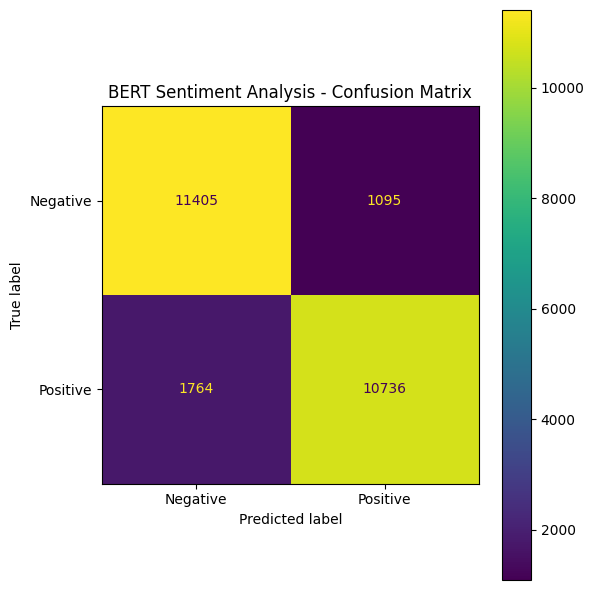

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)

plt.title("BERT Sentiment Analysis - Confusion Matrix")
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.87      0.91      0.89     12500
    Positive       0.91      0.86      0.88     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



In [25]:
import pandas as pd

comparison_results = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "BERT"
    ],
    "Accuracy": [
        0.89,
        0.88564
    ],
    "Precision": [
        0.89,
        0.90745
    ],
    "Recall": [
        0.89,
        0.85888
    ],
    "F1": [
        0.89,
        0.88250
    ]
})

comparison_results

,Model,Accuracy,Precision,Recall,F1
0,TF-IDF + Logistic Regression,0.89000,0.89000,0.89000,0.8900
1,BERT,0.88564,0.90745,0.85888,0.8825


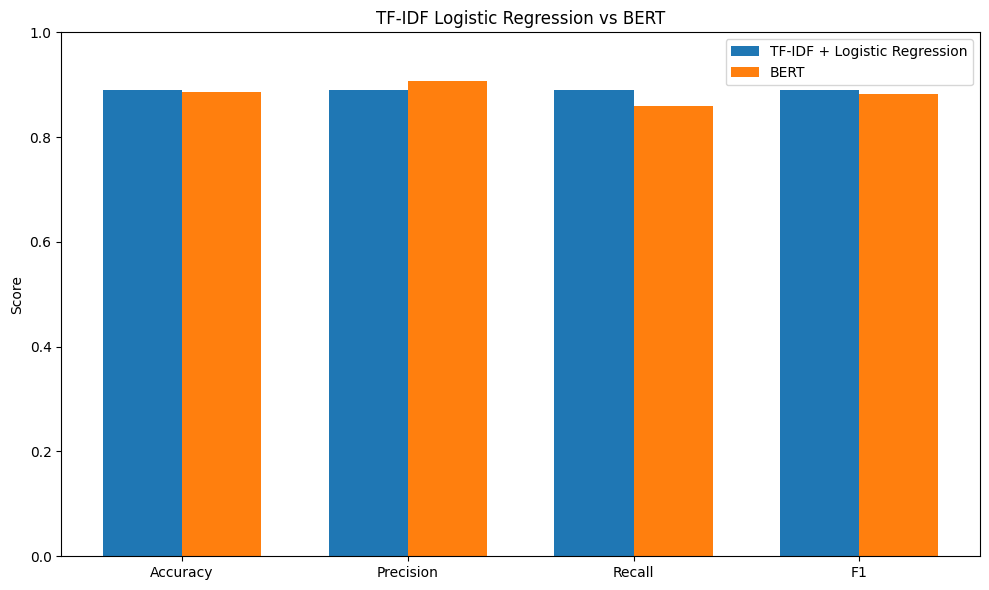

In [26]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1"]

logistic_scores = comparison_results.iloc[0][metrics].values
bert_scores = comparison_results.iloc[1][metrics].values

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, logistic_scores, width, label="TF-IDF + Logistic Regression")
plt.bar(x + width/2, bert_scores, width, label="BERT")

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("TF-IDF Logistic Regression vs BERT")
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
trainer.save_model("bert_model")

tokenizer.save_pretrained("bert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert_model/tokenizer_config.json', 'bert_model/tokenizer.json')

## Conclusion

This project compared a traditional NLP approach, TF-IDF with Logistic Regression, against a fine-tuned BERT transformer model for binary sentiment classification on the IMDB movie-review dataset.

The final BERT model achieved **88.56% accuracy**, **90.74% precision**, **85.89% recall**, and **88.25% F1-score** on the 25,000-review test set.

The TF-IDF + Logistic Regression baseline remained highly competitive, with approximately **89% accuracy and F1-score**.

Therefore, the current experiment does not show that BERT outperformed the traditional baseline on overall accuracy or F1-score. This demonstrates that more complex transformer architectures do not automatically produce better results, and that model performance depends on preprocessing, hyperparameters, sequence length, training configuration, and the characteristics of the dataset.

The project demonstrates practical experience with NLP preprocessing, TF-IDF, Logistic Regression, BERT tokenization, transformer fine-tuning, Hugging Face Transformers, PyTorch, sentiment classification, confusion-matrix analysis, and model comparison.
